In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import joblib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Ingresando dataframe a la variable datos

In [ ]:
datos = pd.read_csv('/content/flights_sample_3m.csv', engine='python');
datos.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLA

In [ ]:
datos.describe(include = "all")

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
count,3000000,3000000,3000000,3000000,3.000000e+06,3.000000e+06,3000000,3000000,3000000,3000000,...,3.000000e+06,2.999986e+06,2.913802e+06,2.913802e+06,3.000000e+06,533863.000000,533863.000000,533863.000000,533863.000000,533863.000000
unique,1704,18,18,18,NaN,NaN,380,373,380,373,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2019-07-25,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,NaN,NaN,ATL,"Chicago, IL",ATL,"Chicago, IL",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2379,576470,576470,576470,NaN,NaN,153556,157368,153569,158087,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,1.997629e+04,2.511536e+03,NaN,NaN,NaN,NaN,...,2.352000e-03,1.422758e+02,1.366205e+02,1.123108e+02,8.093616e+02,24.759086,3.985260,13.164728,0.145931,25.471282
std,NaN,NaN,NaN,NaN,3.772846e+02,1.747258e+03,NaN,NaN,NaN,NaN,...,4.844036e-02,7.155669e+01,7.167582e+01,6.975484e+01,5.878939e+02,71.771845,32.410796,33.161122,3.582053,55.766892
min,NaN,NaN,NaN,NaN,1.939300e+04,1.000000e+00,NaN,NaN,NaN,NaN,...,0.000000e+00,1.000000e+00,1.500000e+01,8.000000e+00,2.900000e+01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,1.979000e+04,1.051000e+03,NaN,NaN,NaN,NaN,...,0.000000e+00,9.000000e+01,8.400000e+01,6.100000e+01,3.770000e+02,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,1.993000e+04,2.152000e+03,NaN,NaN,NaN,NaN,...,0.000000e+00,1.250000e+02,1.200000e+02,9.500000e+01,6.510000e+02,4.000000,0.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,NaN,NaN,2.036800e+04,3.797000e+03,NaN,NaN,NaN,NaN,...,0.000000e+00,1.720000e+02,1.670000e+02,1.420000e+02,1.046000e+03,23.000000,0.000000,17.000000,0.000000,30.000000


Limpiando Datos

In [ ]:
datos.isna().sum().sort_values(ascending=False)

,0
CANCELLATION_CODE,2920860
DELAY_DUE_LATE_AIRCRAFT,2466137
DELAY_DUE_CARRIER,2466137
DELAY_DUE_SECURITY,2466137
DELAY_DUE_NAS,2466137
DELAY_DUE_WEATHER,2466137
ARR_DELAY,86198
ELAPSED_TIME,86198
AIR_TIME,86198
WHEELS_ON,79944


In [ ]:
datos.isna().sum().sort_values(ascending=False) * 100

,0
CANCELLATION_CODE,292086000
DELAY_DUE_LATE_AIRCRAFT,246613700
DELAY_DUE_CARRIER,246613700
DELAY_DUE_SECURITY,246613700
DELAY_DUE_NAS,246613700
DELAY_DUE_WEATHER,246613700
ARR_DELAY,8619800
ELAPSED_TIME,8619800
AIR_TIME,8619800
WHEELS_ON,7994400


In [ ]:
datos['DEP_DELAY'] = datos['DEP_DELAY'].fillna(0)

In [ ]:
datos[datos['CANCELLED'] == 1].isna().sum()

,0
FL_DATE,0
AIRLINE,0
AIRLINE_DOT,0
AIRLINE_CODE,0
DOT_CODE,0
FL_NUMBER,0
ORIGIN,0
ORIGIN_CITY,0
DEST,0
DEST_CITY,0


Separar los vuelos separados

In [ ]:
vuelos_cancelados = datos.loc[datos['CANCELLED'] == 1].copy()
vuelos_operados = datos.loc[datos['CANCELLED'] == 0].copy()
vuelos_operados['FL_DATE'] = pd.to_datetime(vuelos_operados['FL_DATE'], errors='coerce')

In [ ]:
# Verificando si hay fechas invalidas (NaT) despues de la conversion
vuelos_operados[vuelos_operados['FL_DATE'].isna()]

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT


In [ ]:
#retrasos
vuelos_operados[
    (vuelos_operados['DEP_DELAY'] < -60) |
    (vuelos_operados['DEP_DELAY'] > 1000)
]

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
29,2023-04-15,Republic Airline,Republic Airline: YX,YX,20452,3615,MSP,"Minneapolis, MN",EWR,"Newark, NJ",...,0.0,178.0,233.0,145.0,1008.0,0.0,0.0,1124.0,0.0,0.0
3639,2021-12-30,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,696,SLC,"Salt Lake City, UT",LAX,"Los Angeles, CA",...,0.0,120.0,125.0,90.0,590.0,1022.0,0.0,5.0,0.0,0.0
4548,2019-12-20,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,1646,RSW,"Fort Myers, FL",CLT,"Charlotte, NC",...,0.0,120.0,105.0,83.0,600.0,1020.0,0.0,0.0,0.0,0.0
5147,2021-02-01,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,2228,CLT,"Charlotte, NC",EWR,"Newark, NJ",...,0.0,117.0,122.0,76.0,529.0,0.0,1180.0,5.0,0.0,0.0
13746,2021-10-04,SkyWest Airlines Inc.,SkyWest Airlines Inc.: OO,OO,20304,3230,SEA,"Seattle, WA",LAX,"Los Angeles, CA",...,0.0,169.0,162.0,136.0,954.0,0.0,0.0,0.0,0.0,1049.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2974756,2021-02-15,SkyWest Airlines Inc.,SkyWest Airlines Inc.: OO,OO,20304,5077,EAU,"Eau Claire, WI",ORD,"Chicago, IL",...,0.0,74.0,80.0,53.0,269.0,0.0,1086.0,0.0,0.0,0.0
2983586,2020-07-07,SkyWest Airlines Inc.,SkyWest Airlines Inc.: OO,OO,20304,5512,GJT,"Grand Junction, CO",DEN,"Denver, CO",...,0.0,70.0,84.0,39.0,212.0,1470.0,0.0,0.0,0.0,0.0
2990081,2020-02-16,Allegiant Air,Allegiant Air: G4,G4,20368,867,PIA,"Peoria, IL",PIE,"St. Petersburg, FL",...,0.0,135.0,141.0,124.0,965.0,955.0,0.0,6.0,0.0,415.0
2990925,2022-03-09,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,2216,PDX,"Portland, OR",DFW,"Dallas/Fort Worth, TX",...,0.0,226.0,213.0,186.0,1616.0,1859.0,0.0,0.0,0.0,0.0


In [ ]:
vuelos_operados[
    (vuelos_operados['DISTANCE'] <= 0) |
    (vuelos_operados['DISTANCE'] > 15000)
]

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT


## Tipo de dato distancia

#### La variable distance se encuentra el millas

In [ ]:
vuelos_operados['DISTANCE'].describe()

,DISTANCE
count,2.920860e+06
mean,8.110854e+02
std,5.895143e+02
min,2.900000e+01
25%,3.790000e+02
50%,6.550000e+02
75%,1.047000e+03
max,5.812000e+03


## Convirtiendo a Kilometros

In [ ]:
vuelos_operados['DISTANCE_KM'] = vuelos_operados['DISTANCE'] * 1.60934
vuelos_operados['DISTANCE_KM'].describe()

,DISTANCE_KM
count,2.920860e+06
mean,1.305312e+03
std,9.487289e+02
min,4.667086e+01
25%,6.099399e+02
50%,1.054118e+03
75%,1.684979e+03
max,9.353484e+03


## Graficando

### Cancelaciones por aerolinea (en caso de que sea relevante)

<Axes: xlabel='AIRLINE'>

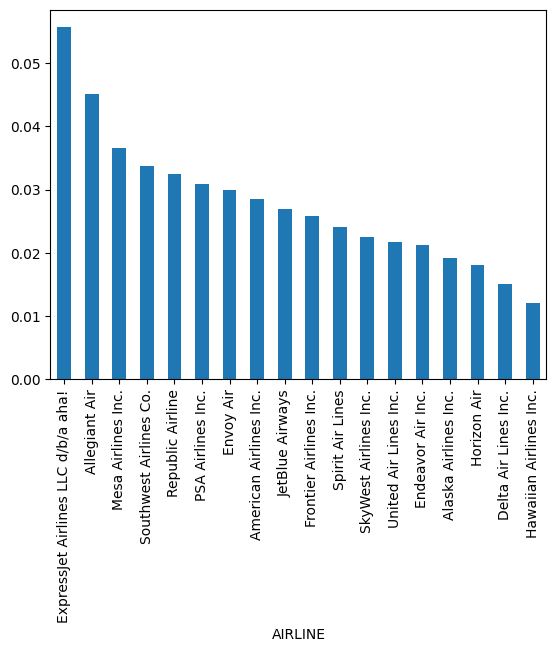

In [ ]:
tasa_cancelacion = (
    datos.groupby('AIRLINE')['CANCELLED'].mean().sort_values(ascending=False)
)
tasa_cancelacion.plot(kind='bar')

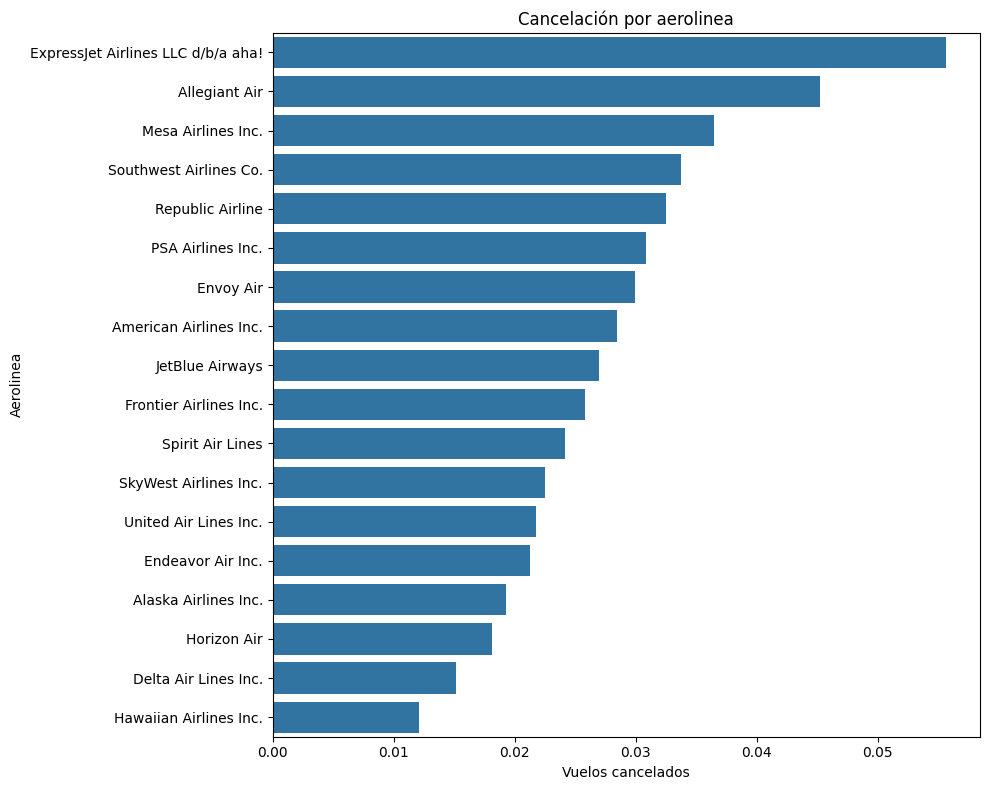

In [ ]:
plt.figure(figsize=(10,8))
sns.barplot(
    y=tasa_cancelacion.index,
    x=tasa_cancelacion.values,
    orient='h'
)
plt.title("Cancelación por aerolinea")
plt.xlabel("Vuelos cancelados")
plt.ylabel("Aerolinea")
plt.tight_layout()
plt.show()

### Retrasos por aerolinea

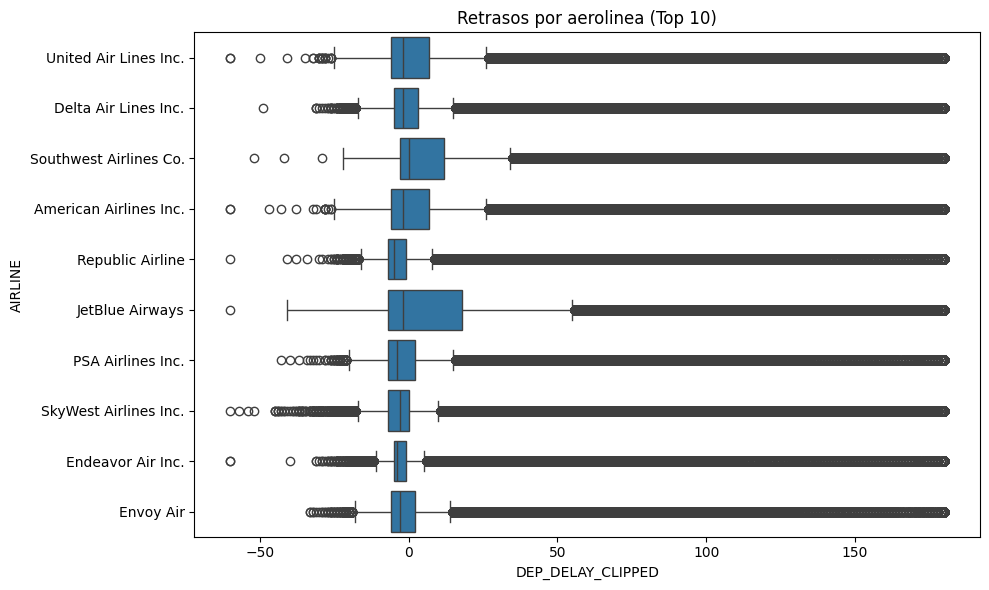

In [ ]:
top_aerolineas = (vuelos_operados['AIRLINE'].value_counts().head(10).index)

datos_top = vuelos_operados[vuelos_operados['AIRLINE'].isin(top_aerolineas)].copy()

datos_top.loc[:, 'DEP_DELAY_CLIPPED'] = datos_top['DEP_DELAY'].clip(lower=-60, upper=180)

plt.figure(figsize=(10,6))
sns.boxplot(data=datos_top, y='AIRLINE', x='DEP_DELAY_CLIPPED')
plt.title('Retrasos por aerolinea (Top 10)')
plt.tight_layout()
plt.show()

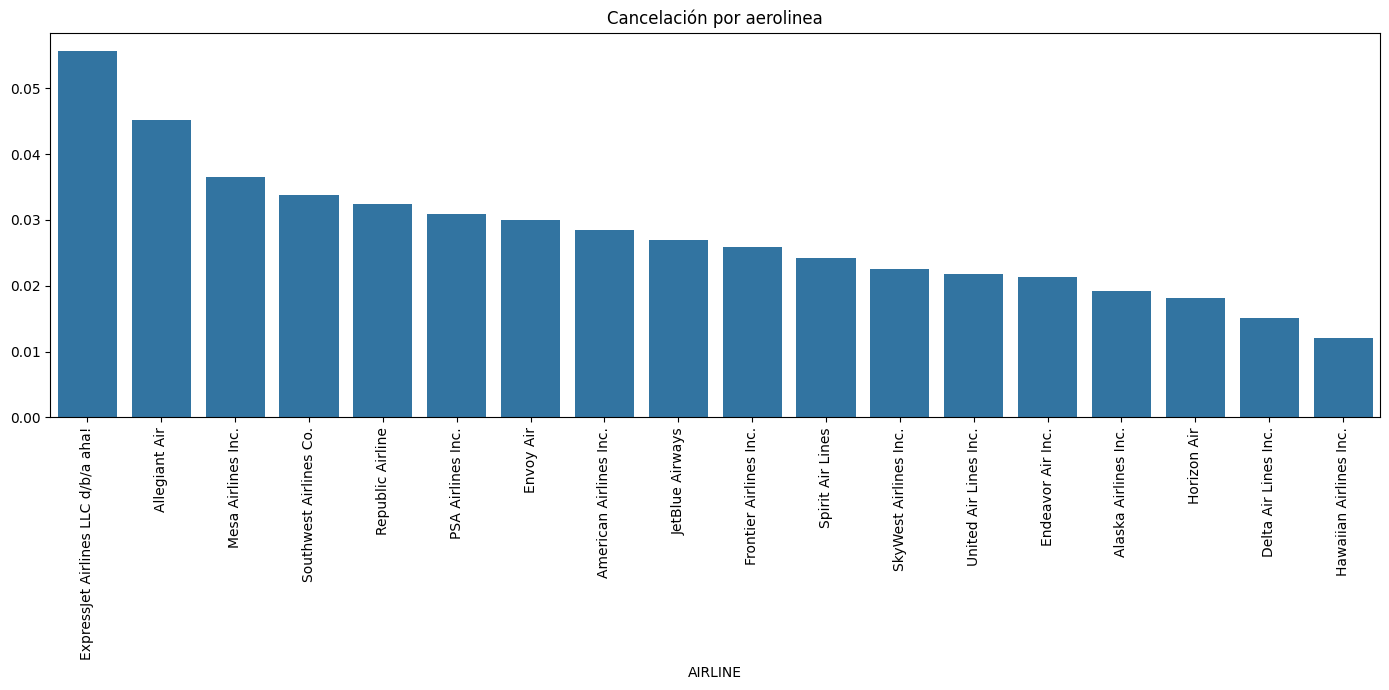

In [ ]:
# En graficas en vertical

plt.figure(figsize=(14,7))
sns.barplot(x=tasa_cancelacion.index, y=tasa_cancelacion.values)
plt.xticks(rotation=90)
plt.title('Cancelación por aerolinea')
plt.tight_layout()
plt.show()

In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLA

## Feature engeeniering

Extracción  de variables de fecha y hora

In [ ]:
#Hora del día
#Dividimos DEP_TIME por 100 para obtener la hora y luego rellenamos nulos
vuelos_operados['DEP_TIME_HOUR'] = (vuelos_operados['DEP_TIME'] // 100).fillna(0).astype(int)

#Día de la semana
#Para que dt.dayofweek nos devuelva 0 = Lunes, 1 = Martes, 2 Miércoles ... 6 = domingo
print(f"FL_DATE dtype before .dt accessor: {vuelos_operados['FL_DATE'].dtype}")
vuelos_operados['DAY_OF_WEEK'] = vuelos_operados['FL_DATE'].dt.dayofweek

#Mes del año
#Extraemos el mes (1=Enero | 12=Diciembre)
vuelos_operados['MONTH'] = vuelos_operados['FL_DATE'].dt.month  #Añadido el 22-12-2025

print("Ejemplo de nuevas variables temporales:")
print(vuelos_operados[['FL_DATE', 'DEP_TIME', 'DEP_TIME_HOUR', 'DAY_OF_WEEK', 'MONTH']].head())

FL_DATE dtype before .dt accessor: datetime64[ns]
Ejemplo de nuevas variables temporales:
     FL_DATE  DEP_TIME  DEP_TIME_HOUR  DAY_OF_WEEK  MONTH
0 2019-01-09    1151.0             11            2      1
1 2022-11-19    2114.0             21            5     11
2 2022-07-22    1000.0             10            4      7
3 2023-03-06    1608.0             16            0      3
4 2020-02-23    1838.0             18            6      2


Codificación de variables categóricas (Label Encoding)

In [ ]:
#Iniciamos los codificadores respectivos
le_aerolinea = LabelEncoder()
le_origen = LabelEncoder()
le_destino = LabelEncoder()

#Entrenamos y transformamos al mismo tiempo
vuelos_operados['aerolinea_encoded'] = le_aerolinea.fit_transform(vuelos_operados['AIRLINE_CODE'])
vuelos_operados['origen_encoded'] = le_origen.fit_transform(vuelos_operados['ORIGIN'])
vuelos_operados['destino_encoded'] = le_destino.fit_transform(vuelos_operados['DEST'])

#Guardamos los encoders para el equipo de Backend
joblib.dump(le_aerolinea, 'le_aerolinea.joblib')
joblib.dump(le_origen, 'le_origen.joblib')
joblib.dump(le_destino, 'le_destino.joblib')

print("Ejemplo de nuevas variables codificadas:")
print(vuelos_operados[['AIRLINE_CODE', 'aerolinea_encoded', 'ORIGIN', 'origen_encoded', 'DEST', 'destino_encoded']].head())



Ejemplo de nuevas variables codificadas:
  AIRLINE_CODE  aerolinea_encoded ORIGIN  origen_encoded DEST  destino_encoded
0           UA                 14    FLL             131  EWR              123
1           DL                  4    MSP             247  SEA              323
2           UA                 14    DEN              99  MSP              247
3           DL                  4    MSP             247  SFO              325
4           NK                 10    MCO             223  DFW              100


Validación final con el contrato

In [ ]:
#Definimos las columnas esenciales para el modelo
columnas_esenciales = [
    'DEP_TIME_HOUR',
    'DAY_OF_WEEK',
    'MONTH',             #Añadido el 22-12-2025
    'aerolinea_encoded',
    'origen_encoded',
    'destino_encoded',
    'DISTANCE_KM']

#Verificamos si existen en nuestra tabla de 'vuelos_operados'
missing_cols = [col for col in columnas_esenciales if col not in vuelos_operados.columns]

print("---REPORTE DE VALIDACIÓN---")
if not missing_cols:
    print("OK, todas las columnas están listas.")
    print("El dataset cumple con el contrato para entrar el modelo")
    print(f"Columnas finales para el modelo (nombre del modelo): {columnas_esenciales}")
else:
    print("ERROR, faltan las siguientes columnas:", missing_cols)

---REPORTE DE VALIDACIÓN---
OK, todas las columnas están listas.
El dataset cumple con el contrato para entrar el modelo
Columnas finales para el modelo (nombre del modelo): ['DEP_TIME_HOUR', 'DAY_OF_WEEK', 'MONTH', 'aerolinea_encoded', 'origen_encoded', 'destino_encoded', 'DISTANCE_KM']


Diccionario con los números a códigos de líneas aéreas

In [ ]:
#Obtenemos las clases (los códigos originales ordenados)
#El índice de la lista es el número asignado por el encoder.
codigos = le_aerolinea.classes_

#Creamos el diccionario: { Número : "Código" }
diccionario_num_a_codigo = {i: codigo for i, codigo in enumerate(codigos)}

#Creamos el diccionario inverso: { "Código" : Número }
diccionario_codigo_a_num = {codigo: i for i, codigo in enumerate(codigos)}

print("--- Diccionario: Número -> Aerolínea ---")
print(diccionario_num_a_codigo)

print("\n--- Diccionario: Aerolínea -> Número (Para la API) ---")
print(diccionario_codigo_a_num)

#'Opcional: Exportar a un archivo JSON real si el equipo de Backend lo prefiere'
import json
with open('mapa_aerolineas.json', 'w') as f:
    json.dump(diccionario_codigo_a_num, f)
    print("\n✅ Archivo 'mapa_aerolineas.json' exportado exitosamente.")

--- Diccionario: Número -> Aerolínea ---
{0: '9E', 1: 'AA', 2: 'AS', 3: 'B6', 4: 'DL', 5: 'EV', 6: 'F9', 7: 'G4', 8: 'HA', 9: 'MQ', 10: 'NK', 11: 'OH', 12: 'OO', 13: 'QX', 14: 'UA', 15: 'WN', 16: 'YV', 17: 'YX'}

--- Diccionario: Aerolínea -> Número (Para la API) ---
{'9E': 0, 'AA': 1, 'AS': 2, 'B6': 3, 'DL': 4, 'EV': 5, 'F9': 6, 'G4': 7, 'HA': 8, 'MQ': 9, 'NK': 10, 'OH': 11, 'OO': 12, 'QX': 13, 'UA': 14, 'WN': 15, 'YV': 16, 'YX': 17}

✅ Archivo 'mapa_aerolineas.json' exportado exitosamente.


Diccionario general que vinculan los códigos originales de las aerolíneas y aeropuertos con los identificadores numéricos generados por los LabelEncoder.

-Este "mapa de traducción" que permite que el microservicio convierta instantáneamente las entradas de texto del usuario en los valores exactos que el modelo requiere para procesar la predicción.

-Al exportar estas equivalencias y los codificadores mediante archivos .joblib, se garantiza que el sistema hable un único idioma técnico y elimino cualquier riesgo de error en la comunicación de datos entre la API y el modelo entrenado.

### Determinación del Target del Modelo

Para este proyecto, el objetivo es predecir si un vuelo saldrá con retraso.  
Para ello, se definio un **target binario** basado en la variable `DEP_DELAY`, que indica los minutos de retraso en la salida del vuelo.

### Estándar utilizado
De acuerdo con la normativa internacional (DOT/IATA), un vuelo se considera **retrasado** cuando presenta **15 minutos o más de demora** en la salida.

### Definición del target
- **1** → Vuelo retrasado (`DEP_DELAY ≥ 15`)
- **0** → Vuelo a tiempo (`DEP_DELAY < 15`)

Esta definición permite entrenar un modelo de clasificación capaz de entregar la **probabilidad de retraso**, que es el resultado requerido por el cliente y utilizado por el frontend del proyecto.

### Validación y preparación de la variable base `DEP_DELAY`

Antes de construir el target, es necesario asegurar que la variable `DEP_DELAY` esté en condiciones de ser utilizada.  
Para ello, se realiza lo siguiente:

- Se trabaja únicamente con vuelos operados (no cancelados ni desviados), ya que en esos casos no es posible determinar un retraso real en la salida.
- Se excluyen registros sin información en `DEP_DELAY`, dado que no permiten clasificar el vuelo como retrasado o a tiempo.
- Se verifica que los valores extremos o inconsistentes sean mínimos y no afecten la definición del target.

Este proceso garantiza que el target se construya sobre datos válidos y coherentes con la operación real.

In [ ]:
# Filtrar solo vuelos operados (no cancelados ni desviados)
vuelos_operados = datos.loc[
    (datos['CANCELLED'] == 0) &
    (datos['DIVERTED'] == 0)
].copy()

# Eliminar registros sin DEP_DELAY
vuelos_operados = vuelos_operados[~vuelos_operados['DEP_DELAY'].isna()].copy()

# Crear el target binario
vuelos_operados['DELAYED'] = (vuelos_operados['DEP_DELAY'] >= 15).astype(int)

# Revisión rápida del balance de clases
vuelos_operados['DELAYED'].value_counts(normalize=True)

,proportion
DELAYED,
0,0.818549
1,0.181451


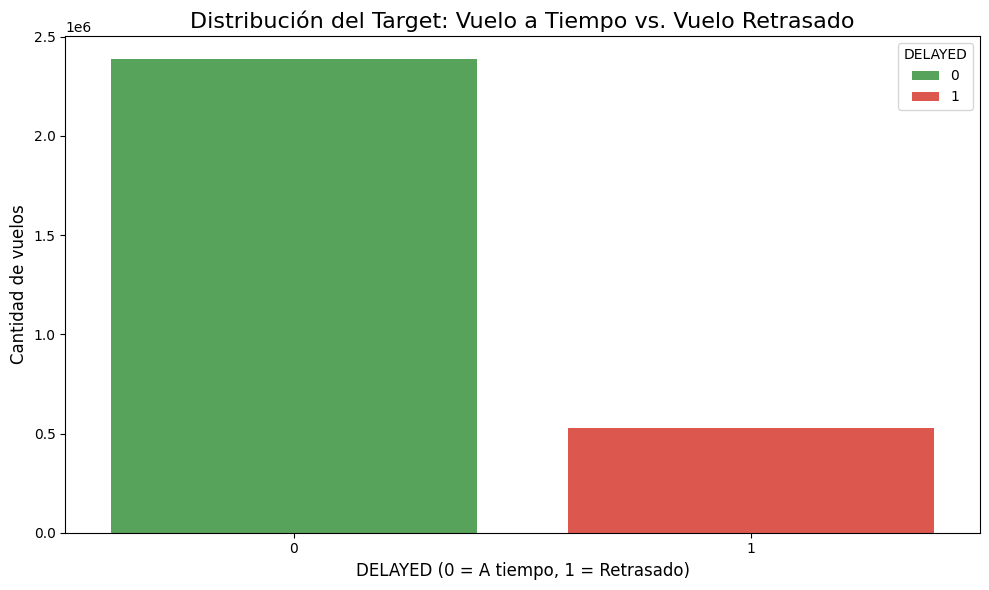

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='DELAYED',
    hue='DELAYED',
    data=vuelos_operados,
    palette=['#4CAF50', '#F44336']  # Verde = a tiempo, rojo = retrasado
   )

plt.title('Distribución del Target: Vuelo a Tiempo vs. Vuelo Retrasado', fontsize=16)
plt.xlabel('DELAYED (0 = A tiempo, 1 = Retrasado)', fontsize=12)
plt.ylabel('Cantidad de vuelos', fontsize=12)

plt.tight_layout()
plt.show()

### Interpretación del gráfico

En el gráfico se puede ver claramente cómo se distribuyen los vuelos entre aquellos que salen a tiempo (`DELAYED = 0`) y los que presentean un retraso de 15 minutos o más (`DELAYED = 1`).

La revisión es fundamental porque:

- Permite detectar si existe un desbalance entre ambasclases, algo que más adelante influirá en las métricas y en las decisiones de modelado.
- También confirma que la construcción del target es coherente con los datos disponibles.
- Además asegura que el modelo se entrenará con información representativa de la operación real, lo que aumenta la confiabilidad de los resultados.

Con esta etapa, la determinación del target queda completamente definida y validada.


#Entrenamiento del modelo.


##Importacion de las librerias necesarias.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [ ]:
vuelos_operados['DISTANCE_KM'] = vuelos_operados['DISTANCE'] * 1.60934
vuelos_operados['DISTANCE_KM'].head()

,DISTANCE_KM
0,1713.94710
1,2251.46666
2,1094.35120
3,2557.24126
4,1585.19990


In [ ]:
#Se busca una columna la cual contenga datos de los retrasos.
columna_retraso = 'ARR_DELAY' if 'ARR_DELAY' in vuelos_operados.columns else [c for c in vuelos_operados.columns if 'DELAY' in c][0]

#Se separan las columnas que se utilizaran para los modelos.
cols_existentes = [c for c in ['AIRLINE', 'ORIGIN', 'DEST', 'DISTANCE_KM', 'DAY_OF_WEEK'] if c in vuelos_operados.columns]
columnas_finales = cols_existentes + [columna_retraso]

#Se crea el dataframe con el que se va a trabajar, eliminando nulos.
df_trabajo = vuelos_operados[columnas_finales].dropna().copy()

#Se fuerza la conversión a número para evitar el errores con los tipos en las columnas de datos.
for col in ['DISTANCE_KM', 'DAY_OF_WEEK', columna_retraso]:
    if col in df_trabajo.columns:
        df_trabajo[col] = pd.to_numeric(df_trabajo[col], errors='coerce')

#Se eliminan los valores nulos para el data frame final.
df_trabajo = df_trabajo.dropna()

#Se definen los datos para X y los datos para y.
y = (df_trabajo[columna_retraso] > 15).astype(int)
X = df_trabajo[cols_existentes].copy()

#Se codifican las categorías.
le = LabelEncoder()
for col in ['AIRLINE', 'ORIGIN', 'DEST','DISTANCE_KM']:
    if col in X.columns:
        X[col] = le.fit_transform(X[col].astype(str))

print("Realizado correctamente")
print(f"Registros finales para entrenar el modelo: {len(X)}")
X.head()

Realizado correctamente
Registros finales para entrenar el modelo: 2913802


,AIRLINE,ORIGIN,DEST,DISTANCE_KM
0,17,131,123,450
1,3,247,323,726
2,17,99,247,57
3,3,247,325,855
4,16,223,100,369


##Separación de los datos de entrenamiento y prueba para el modelo.

Se hara una separación del 80% de los datos para el entrenamiento del modelo y el 20% de los datos para la prueba del modelo.

Estos datos que se separan son los datos que se limpiaron, eliminaron o agregaron columnas consideradas necesarias para la creación de modelo.

In [ ]:
#Separación de los datos de entrenamiento y prueba, 80% para entrenamiento y 20% para prueba de los modelos.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression.
param_log = {'C': [0.1, 1.0, 10]}
grid_log = GridSearchCV(LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear'),
                        param_log, cv=3, scoring='f1')
grid_log.fit(X_train, y_train)
modelo_log_final = grid_log.best_estimator_

# Random Forest.
param_rf = {'n_estimators': [100, 150], 'max_depth': [10]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42, class_weight='balanced'),
                       param_rf, cv=3, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train, y_train)
modelo_rf_final = grid_rf.best_estimator_

print("¡Modelos entrenados!")

¡Modelos entrenados!


##Modelos de Logistic Regression y Random Forest.
###Para que los modelos no solo procesen datos, sino que aprenda de los patrones en los datos, se le aplico lo siguiente:
####Los hiperparametros estos son configuraciones externas que ayuda a definir una estructura para el modelo. Se hace uso de GrisSearchCV para probar distintas combinaciones, evitando que el modelo adivine los valores y asi asegurarque el modelo encuentre su optimo rendimiento.
###Ajustes especificos
####Balanceo de clases ya que la mayoria de vuelos en el data set son puntuales, el configurar esto obliga al modelo a dar la misma importancia a los vulos atrasados, esto evita que el modelo omita estos datos por ser una minoria.
####Regularización en la regresion logístiva, esto controla la sencibilidad del modelo con datos no comunes, esto evita variables ruidosas que distorcionen la predicción.
####Profundidad y arbooles en el modelo de Random Forest se limita la profundidad para que el modelo aprenda reglas de forma general y no simplemente memorice vuelos en especifico.


#Evaluación de los modelos.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def obtener_metricas(nombre, modelo, X_test, y_test):
    preds = modelo.predict(X_test)
    return {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-score': f1_score(y_test, preds)
    }

# Calculamos métricas para ambos modelos ajustados
metricas_log = obtener_metricas('Logistic Regression', modelo_log_final, X_test, y_test)
metricas_rf = obtener_metricas('Random Forest', modelo_rf_final, X_test, y_test)

#Se crea un tabla comparativa
tabla_comparativa = pd.DataFrame([metricas_log, metricas_rf])

#Se muestra la tabla formateada
print("TABLA COMPARATIVA DE RENDIMIENTO")
display(tabla_comparativa)

TABLA COMPARATIVA DE RENDIMIENTO


,Modelo,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.525869,0.186878,0.503296,0.272554
1,Random Forest,0.561935,0.213477,0.552175,0.307912


#Eleccion del modelo ganador
##El modelo seleccionado es el Random Forest por:
#### Mejor equilibrio, este presenta un F1-score mas alto, lo que significa que tiene un buen equilibrio entre la precisión y la vuelos realmente atrasados.
#### Estabilidad al ser este un modelo de ensamble, es más a datos no tan consistentes en el dato set.
#### Detección de patrones este modelo logra comprender de mejor manera la relaciones entre las aerolineas, destinos y distancias comparado con un modelo lineal simple como el modelo de Logistic Regression.

# Serialización del Modelo

En esta sección se realiza la serialización del modelo entrenado junto con los encoders y el orden de las variables utilizadas.

Este proceso permite reutilizar el modelo en otros entornos sin necesidad de reentrenarlo, asegurando coherencia en la transformación de los datos y en la estructura de entrada esperada por el modelo.

In [ ]:
import pickle

#1. Guardar el modelo entrenado
with open('modelo_entrenado.pkl', 'wb') as archivo:
    pickle.dump(modelo_rf_final, archivo)

#2. Guardar los encoders
with open ('encoder.pkl', 'wb') as archivo:
    pickle.dump({'le_aerolinea': le_aerolinea, 'le_origen': le_origen, 'le_destino': le_destino}, archivo)

# 3. Guardar el orden de las features
features_modelo = ['AIRLINE', 'ORIGIN', 'DEST', 'DISTANCE_KM', 'DAY_OF_WEEK']
with open('features_modelo.pkl', 'wb') as archivo:
    pickle.dump(features_modelo, archivo)
print("Modelo, encoders y features guardados correctamente.")

Modelo, encoders y features guardados correctamente.
